# Demo: BioTuring Logo Warp

Composed transform demo using `warp_transform()` with a BioTuring logo.

- **Input**: `bioturing_input.png` (RGB image, H x W x 3)
- **Transform**: Composed — Affine (rotate + scale) then TPS (wave distortion)
- **Output**: Warped image side-by-side with original

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

from spatialx_transform import warp_transform
from spatialx_transform.transforms import Affine, TPS, Composed
from spatialx_transform.params import AffineParams, TPSParams, ComposedParams

In [2]:
# Load logo: cv2 reads as [H, W, 3] BGR
img_bgr = cv.imread("bioturing_input.png")
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Convert to [C, H, W] for warp_transform
img_chw = np.transpose(img_rgb, (2, 0, 1))
print(f"Input shape: {img_chw.shape}")

Input shape: (3, 2500, 5000)


In [3]:
# --- Transform 1: Affine (rotate 10deg + scale 1.1x) ---
angle = 10 * np.pi / 180
s = 1.1
A = [[s * np.cos(angle), -s * np.sin(angle)], [s * np.sin(angle), s * np.cos(angle)]]
affine_tf = Affine(params=AffineParams(A=A, b=[0.0, 0.0]))

# --- Transform 2: TPS (wave distortion) ---
# Control points spread across the image (x=col, y=row)
control_points = [
    500,
    500,
    2500,
    500,
    4500,
    500,
    500,
    1250,
    2500,
    1250,
    4500,
    1250,
    500,
    2000,
    2500,
    2000,
    4500,
    2000,
]
# Alternating weights create a wavy ripple effect
weights_x = [
    1.5e-5,
    -1.5e-5,
    1.5e-5,
    -1.5e-5,
    2.0e-5,
    -1.5e-5,
    1.5e-5,
    -1.5e-5,
    1.5e-5,
]
weights_y = [
    -0.8e-5,
    0.8e-5,
    -0.8e-5,
    0.8e-5,
    -1.0e-5,
    0.8e-5,
    -0.8e-5,
    0.8e-5,
    -0.8e-5,
]
tps_tf = TPS(
    params=TPSParams(
        affine_params=AffineParams(A=[[1.0, 0.0], [0.0, 1.0]], b=[0.0, 0.0]),
        weights_x=weights_x,
        weights_y=weights_y,
        control_points=control_points,
    )
)

# --- Composed: apply affine first, then TPS wave ---
tf = Composed(params=ComposedParams(transforms=[affine_tf, tps_tf]))
print(f"Composed transform: {len(tf.params.transforms)} sub-transforms")

Composed transform: 2 sub-transforms


In [4]:
# Warp
result = warp_transform(
    img_chw, tf, d=(20, 20), scale=(1.0, 1.0), chunk_size=(100, 100), preflight=False
)
print(f"Output shape: {result.img_shape}")
print(f"Offset: {result.offset}")

Output shape: [3, 3646, 5902]
Offset: (-1288, 2205)


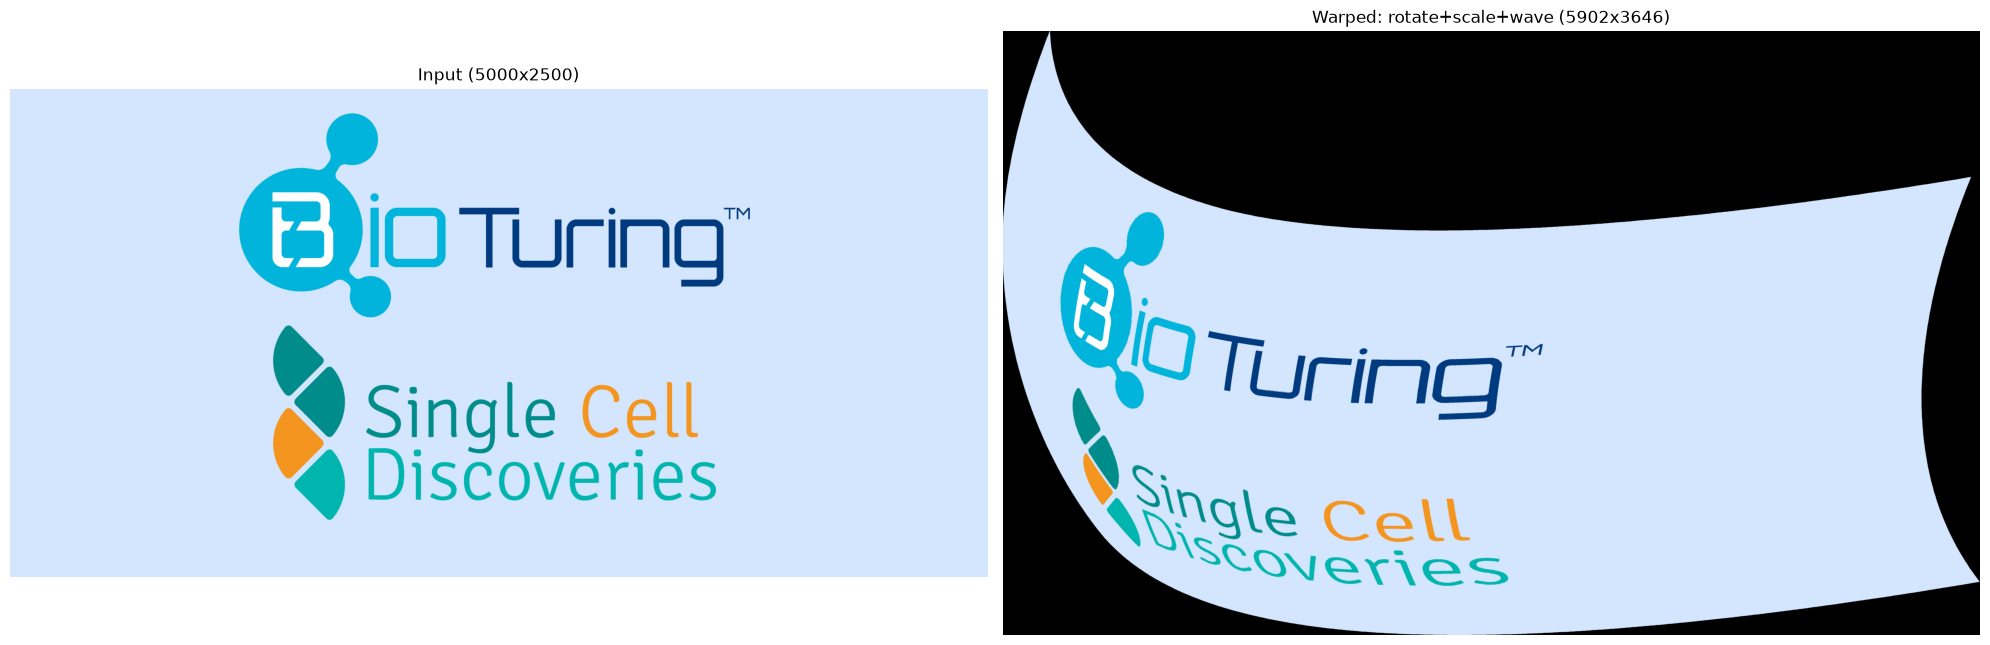

In [5]:
# Convert back to HWC for display
output_rgb = np.transpose(result.img, (1, 2, 0))

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(img_rgb)
axes[0].set_title(f"Input ({img_rgb.shape[1]}x{img_rgb.shape[0]})")
axes[0].axis("off")
axes[1].imshow(output_rgb)
axes[1].set_title(
    f"Warped: rotate+scale+wave ({output_rgb.shape[1]}x{output_rgb.shape[0]})"
)
axes[1].axis("off")
plt.tight_layout()
plt.show()